<a href="https://colab.research.google.com/github/vaishnavi-umasankar/telco-customer-churn-prediction/blob/main/Telco_Churn.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>


**Telco Customer Churn Prediction**

# Telco Customer Churn Prediction — Marketing Analytics Project

**Author:** Vaishu | MBA Business Analytics, CHRIST (Deemed to be University)

**Business Problem:** Telecom companies lose revenue when customers churn, and acquiring a
new customer costs far more than retaining one. This project builds a classification model
to predict which customers are likely to churn, so the marketing/retention team can target
them proactively with retention offers — instead of running blanket campaigns or reacting
only after the customer has already left.

**Dataset:** Telco Customer Churn (7,043 customers, 21 features) — includes tenure,
contract type, monthly/total charges, internet & payment details, and the churn label.

**What this notebook does:**
1. Cleans and explores the data (EDA) to identify key churn drivers
2. Trains 4 classification models — Logistic Regression, Decision Tree, Random Forest, GB Classifier.
3. Evaluates each on Accuracy, Precision, Recall, F1-Score, and ROC-AUC
4. Builds a model comparison leaderboard to identify the best-performing model

In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
import seaborn as sns
from sklearn.svm import SVC

In [2]:
df=pd.read_csv('/content/Telco-Customer-Churn dataset.csv')

In [3]:
df.columns

Index(['customerID', 'gender', 'SeniorCitizen', 'Partner', 'Dependents',
       'tenure', 'PhoneService', 'MultipleLines', 'InternetService',
       'OnlineSecurity', 'OnlineBackup', 'DeviceProtection', 'TechSupport',
       'StreamingTV', 'StreamingMovies', 'Contract', 'PaperlessBilling',
       'PaymentMethod', 'MonthlyCharges', 'TotalCharges', 'Churn'],
      dtype='object')

In [4]:
df.head()

,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,...,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,7590-VHVEG,Female,0,Yes,No,1,No,No phone service,DSL,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,No
1,5575-GNVDE,Male,0,No,No,34,Yes,No,DSL,Yes,...,Yes,No,No,No,One year,No,Mailed check,56.95,1889.5,No
2,3668-QPYBK,Male,0,No,No,2,Yes,No,DSL,Yes,...,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,Yes
3,7795-CFOCW,Male,0,No,No,45,No,No phone service,DSL,Yes,...,Yes,Yes,No,No,One year,No,Bank transfer (automatic),42.30,1840.75,No
4,9237-HQITU,Female,0,No,No,2,Yes,No,Fiber optic,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,Yes


In [5]:
df.isna().sum()

,0
customerID,0
gender,0
SeniorCitizen,0
Partner,0
Dependents,0
tenure,0
PhoneService,0
MultipleLines,0
InternetService,0
OnlineSecurity,0


<h3>Looks like the dataset has no na values.. <h3>

In [6]:
df[df.Churn=='Yes'].shape[0]/df[df.Churn=='No'].shape[0] #Not too severely imbalanced

0.36122922303826827

In [7]:
df.describe()

,SeniorCitizen,tenure,MonthlyCharges
count,7043.000000,7043.000000,7043.000000
mean,0.162147,32.371149,64.761692
std,0.368612,24.559481,30.090047
min,0.000000,0.000000,18.250000
25%,0.000000,9.000000,35.500000
50%,0.000000,29.000000,70.350000
75%,0.000000,55.000000,89.850000
max,1.000000,72.000000,118.750000


In [8]:
#TotalCharges is not present above, Let's see dtype of TotalCharges column
np.dtype(df.TotalCharges)

dtype('O')

In [9]:
#Let's convert it to a numeric type
df.TotalCharges=pd.to_numeric(df.TotalCharges)

ValueError: Unable to parse string " " at position 488

In [10]:
#By looking at the above error, we can understand the reason behind the dtype('o')

len(df[df.TotalCharges==' ']) #We have 11 records with Total Charges value -> ' ' and all these rows have Churn value 'NO', let's remove these rows from our analysis (Having information on Churned customers is more important than info on unchurned records)
df=df[df.TotalCharges!=' ']

df.TotalCharges=pd.to_numeric(df.TotalCharges)
np.dtype(df.TotalCharges)


dtype('float64')

In [11]:
df.describe()

,SeniorCitizen,tenure,MonthlyCharges,TotalCharges
count,7032.000000,7032.000000,7032.000000,7032.000000
mean,0.162400,32.421786,64.798208,2283.300441
std,0.368844,24.545260,30.085974,2266.771362
min,0.000000,1.000000,18.250000,18.800000
25%,0.000000,9.000000,35.587500,401.450000
50%,0.000000,29.000000,70.350000,1397.475000
75%,0.000000,55.000000,89.862500,3794.737500
max,1.000000,72.000000,118.750000,8684.800000


In [12]:
#Ideally SeniorCitizen column should be a factor, so let's convert 1,0 values to Yes,No and later we can label encode all factor columns

df.SeniorCitizen=df.SeniorCitizen.apply(lambda x: 'Yes' if x==1 else 'No')
df.SeniorCitizen.value_counts()

,count
SeniorCitizen,
No,5890
Yes,1142


In [13]:
# df.MultipleLines.value_counts()
# df.DeviceProtection.value_counts()
# df.OnlineBackup.value_counts()
# df.OnlineSecurity.value_counts()
# df.StreamingMovies.value_counts()
# df.StreamingTV.value_counts()
# df.TechSupport.value_counts()


In [14]:
cat_cols_for_wrangling=['MultipleLines','DeviceProtection','OnlineBackup','OnlineSecurity','StreamingMovies','StreamingTV','TechSupport','InternetService']

In [15]:
#Some Data Wrangling.. We will Convert values like 'No Phone Service', 'No Internet Service' to 'No'. In other words, we're creating binary columns (Yes or No)

for col in cat_cols_for_wrangling:
    df[col]=df[col].apply(lambda x: 'No' if 'No' in x else 'Yes')

In [16]:
df.columns

Index(['customerID', 'gender', 'SeniorCitizen', 'Partner', 'Dependents',
       'tenure', 'PhoneService', 'MultipleLines', 'InternetService',
       'OnlineSecurity', 'OnlineBackup', 'DeviceProtection', 'TechSupport',
       'StreamingTV', 'StreamingMovies', 'Contract', 'PaperlessBilling',
       'PaymentMethod', 'MonthlyCharges', 'TotalCharges', 'Churn'],
      dtype='object')

In [17]:
cols=df.columns
cols=cols.drop(['customerID','MonthlyCharges','TotalCharges'])
all_cat_cols=list(cols) #All the categorical features that are required for analysis, we'll remove customerID since it's just an ID column with no significance for the analysis

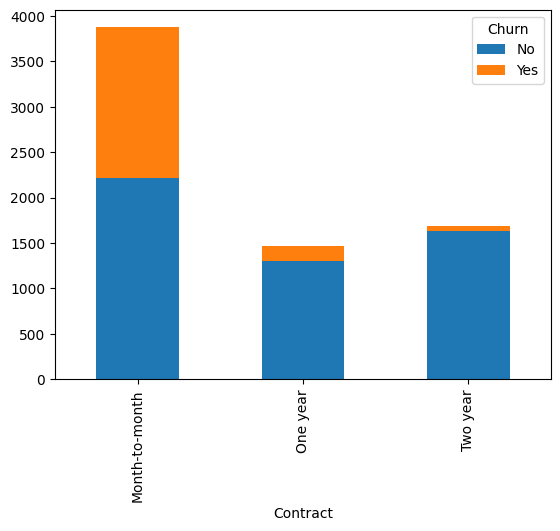

In [18]:
df.groupby(['Contract','Churn']).size().unstack().plot(kind='bar',stacked=True); #Clearly, users with Month-to-Month contract are more likely to churn

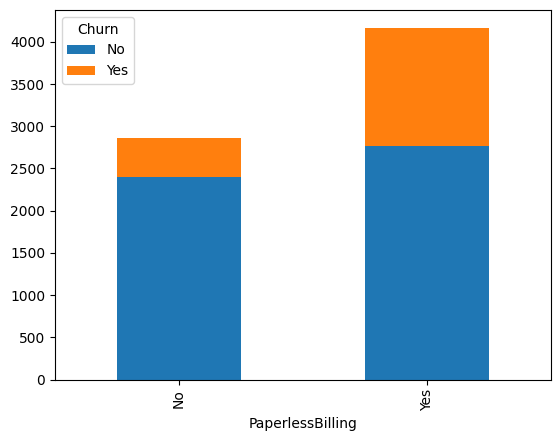

In [19]:
df.groupby(['PaperlessBilling','Churn']).size().unstack().plot(kind='bar',stacked=True);

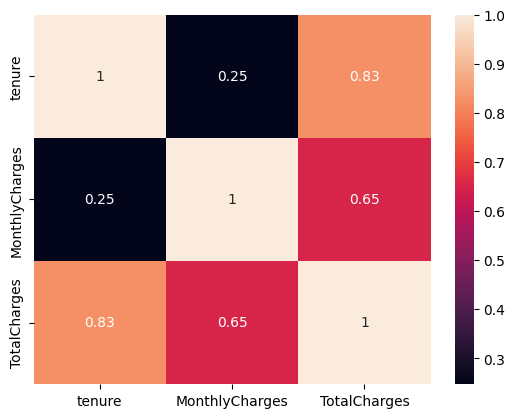

In [23]:
numeric_df = df.drop('customerID', axis=1).select_dtypes(include=np.number)
sns.heatmap(numeric_df.corr(), annot=True);
#Tenure and TotalCharges, Monthly and TotalCharges are corelated and it makes sense,as totalcharges = tenure*MonthlyCharges

In [25]:
#It makes more sense to categorize customers wrt tenure, so let's convert tenure column to tenure range/buckets

def convert_to_buckets(tenure):

    if tenure <=24:
        return '0 - 24 months'
    elif tenure <=36:
        return '24 - 36 months'
    elif tenure <=48:
        return '36 - 48 months'
    elif tenure <=60:
        return '48 - 60 months'
    else:
        return '> 60 months'

In [26]:
df['tenure']=df['tenure'].map(convert_to_buckets)
df['tenure'].value_counts()

,count
tenure,
0 - 24 months,3199
> 60 months,1407
24 - 36 months,832
48 - 60 months,832
36 - 48 months,762


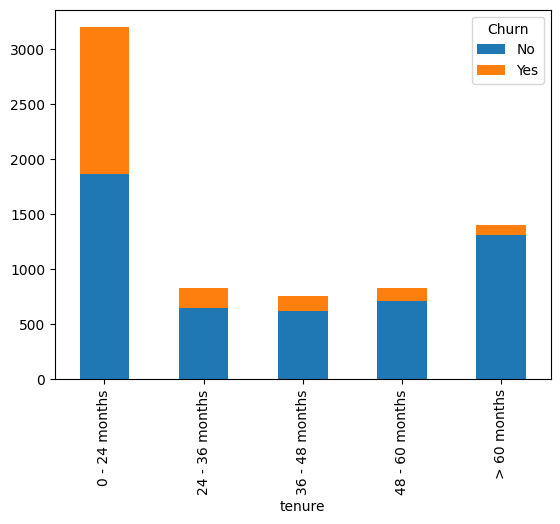

In [27]:
df.groupby(['tenure','Churn']).size().unstack().plot(kind='bar',stacked=True); #customers with 0-24 months tenure are more likely to churn..
#From the plot, it is evident that 'tenure' is an important feature as well./

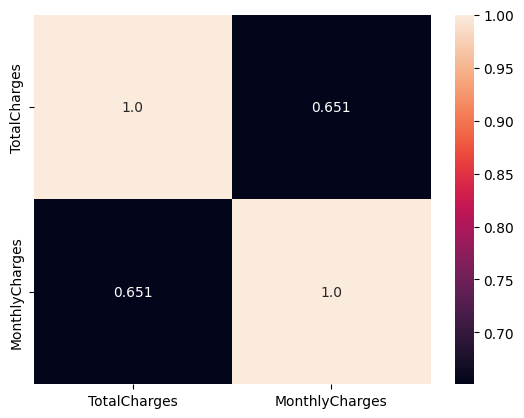

In [28]:
sns.heatmap(df[['TotalCharges','MonthlyCharges']].corr(),annot=True,fmt='.3');
#Since, monthly and Total Charges are corelated.. We'd need to remove one of them, let's remove TotalCharges..

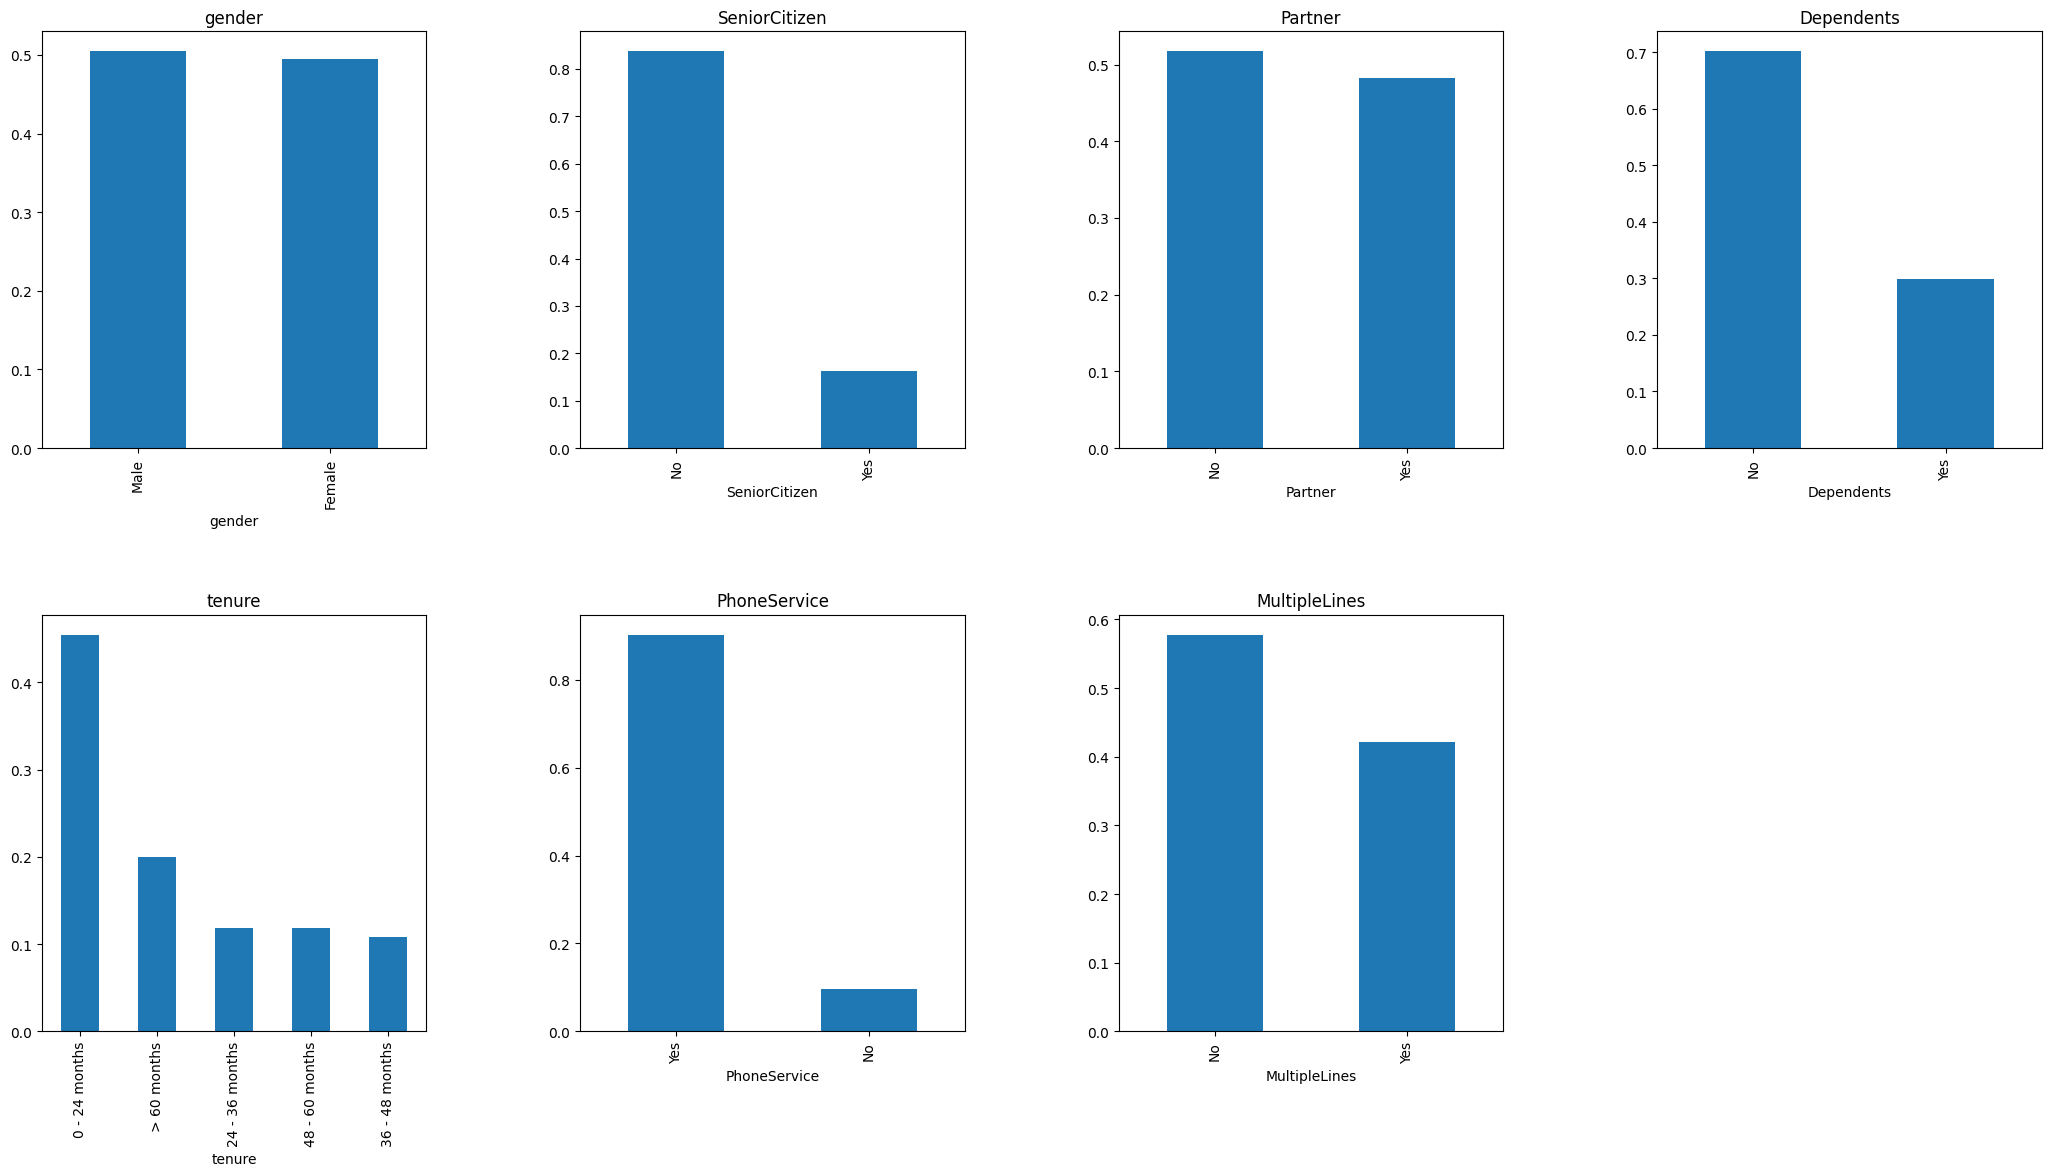

In [31]:
f=plt.figure(figsize=(10,10));
for i in range(7):
    f.add_subplot(2,4,i+1)
    df[all_cat_cols[i]].value_counts(normalize=True).plot(kind='bar',title=all_cat_cols[i])
plt.subplots_adjust(left=3,right=5,top=3,bottom=2,wspace = 0.4,hspace = 0.4)

In [32]:
all_cat_cols #All Categorical column names

['gender',
 'SeniorCitizen',
 'Partner',
 'Dependents',
 'tenure',
 'PhoneService',
 'MultipleLines',
 'InternetService',
 'OnlineSecurity',
 'OnlineBackup',
 'DeviceProtection',
 'TechSupport',
 'StreamingTV',
 'StreamingMovies',
 'Contract',
 'PaperlessBilling',
 'PaymentMethod',
 'Churn']

In [33]:
from sklearn.preprocessing import LabelEncoder
labelencoder = LabelEncoder()

for col in all_cat_cols:
    df[col] = labelencoder.fit_transform(df[col])


df[all_cat_cols].head()

,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,OnlineBackup,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,Churn
0,0,0,1,0,0,0,0,1,0,1,0,0,0,0,0,1,2,0
1,1,0,0,0,1,1,0,1,1,0,1,0,0,0,1,0,3,0
2,1,0,0,0,0,1,0,1,1,1,0,0,0,0,0,1,3,1
3,1,0,0,0,2,0,0,1,1,0,1,1,0,0,1,0,0,0
4,0,0,0,0,0,1,0,1,0,0,0,0,0,0,0,1,2,1


<h3>Train - Test Data split<h3>

In [34]:
#from sklearn.model_selection import train_test_split

X_train=df.sample(frac=0.8,random_state=199)
X_test=df.drop(X_train.index)
len(X_train),len(X_test)

(5626, 1406)

In [35]:
Y_train=X_train['Churn']
Y_test=X_test['Churn']

In [36]:
#Monthly and TotalCharges are corelated, so we remove one of them, we're removing total charges

X_train.drop(columns=['Churn','customerID','TotalCharges'],axis=1,inplace=True)
X_test.drop(columns=['Churn','customerID','TotalCharges'],axis=1,inplace=True)

X_train.columns

Index(['gender', 'SeniorCitizen', 'Partner', 'Dependents', 'tenure',
       'PhoneService', 'MultipleLines', 'InternetService', 'OnlineSecurity',
       'OnlineBackup', 'DeviceProtection', 'TechSupport', 'StreamingTV',
       'StreamingMovies', 'Contract', 'PaperlessBilling', 'PaymentMethod',
       'MonthlyCharges'],
      dtype='object')

Now, We're ready to go for model building, but before we do it.. Let's understand the metrics that matter for this specific problem.


*  Our ultimate goal is to retain as many churning customers as we can. We don't care much if we predict a customer to be churning turns out not churning ie., our Model should have more True positives and less False Negatives. It doesn't matter if we have many False Positives because we care more about no. of false Negatives. The less the no. of False Negatives, the more we're sure about retention..


Just to be clear: In our scenario/perspective:

* A False Positive is when we predict a customer to be churning turns out to be not Churning.
* A False Negative is when we predict a customer to be not churning turns out to be Churning.

It doesn't cost us much if we give an exciting offer (expensive for comapany) to a loyal customer who's not about to leave us. But it costs us a lot if we don't interact/give an offer to a customer who's about to leave us soon. (Because It's a standard rule that acquiring a customer costs more than retaining one.)



---

So, the metric we're looking for is  --> **RECALL**

Recall=TP/TP+FN

Recall gives us the measure of - What proportion of Churned Customers have we retained/Predicted. The less False Negatives we get, The more recall we have... Let's go ahead and build the model



<h2>Model Building<h2>
<h3>Logistic Regression<h3>

In [37]:
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score,confusion_matrix,classification_report

log_model=LogisticRegression(class_weight='balanced')#https://stackoverflow.com/questions/30972029/how-does-the-class-weight-parameter-in-scikit-learn-work
log_model.fit(X_train,Y_train)

Y_pred=log_model.predict(X_test)

/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_logistic.py:465: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


In [38]:
accuracy_score(Y_pred,Y_test)

0.7290184921763869

In [39]:
print(classification_report(Y_pred,Y_test))

              precision    recall  f1-score   support

           0       0.71      0.90      0.79       803
           1       0.79      0.50      0.61       603

    accuracy                           0.73      1406
   macro avg       0.75      0.70      0.70      1406
weighted avg       0.74      0.73      0.72      1406



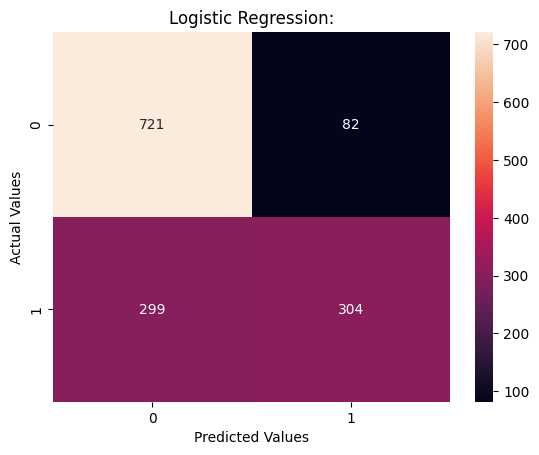

In [40]:
sns.heatmap(confusion_matrix(Y_pred,Y_test),annot=True,fmt='1')
plt.xlabel('Predicted Values')
plt.ylabel('Actual Values')
plt.title('Logistic Regression:'); #';' to exclude printing 'plt' object details

In [43]:
Y_probs = log_model.predict_proba(X_test)[:, 1]
Y_pred1={}

for i in range(1,6):

    Y_pred1['0.'+str(15*i)]=pd.Series(Y_probs).apply(lambda x: 1 if x>0.15*i else 0)
    print('Threshold at ','0.'+str(15*i),':\n',classification_report(Y_pred1['0.'+str(15*i)],Y_test),'\n')

Threshold at  0.15 :
               precision    recall  f1-score   support

           0       0.38      0.96      0.54       397
           1       0.96      0.37      0.53      1009

    accuracy                           0.54      1406
   macro avg       0.67      0.67      0.54      1406
weighted avg       0.80      0.54      0.54      1406
 

Threshold at  0.30 :
               precision    recall  f1-score   support

           0       0.53      0.94      0.68       575
           1       0.91      0.42      0.58       831

    accuracy                           0.64      1406
   macro avg       0.72      0.68      0.63      1406
weighted avg       0.76      0.64      0.62      1406
 

Threshold at  0.45 :
               precision    recall  f1-score   support

           0       0.68      0.91      0.77       761
           1       0.81      0.49      0.61       645

    accuracy                           0.71      1406
   macro avg       0.74      0.70      0.69      1406
weig

<h2>Random Forest Classifier<h2>

In [44]:
from sklearn.ensemble import RandomForestClassifier

rf_model=RandomForestClassifier()

In [45]:
rf_model.fit(X_train,Y_train)

RandomForestClassifier()

In [46]:
Y_rf_Pred=rf_model.predict(X_test)

In [47]:
#list(zip(list(rf_model.predict_proba(X_test)[:,0]),Y_pred.tolist()))

In [48]:
print(classification_report(Y_rf_Pred,Y_test))

              precision    recall  f1-score   support

           0       0.90      0.81      0.85      1126
           1       0.45      0.62      0.53       280

    accuracy                           0.78      1406
   macro avg       0.68      0.72      0.69      1406
weighted avg       0.81      0.78      0.79      1406



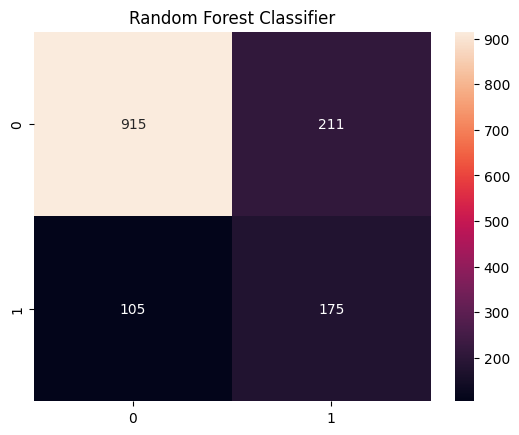

In [49]:
sns.heatmap(confusion_matrix(Y_rf_Pred,Y_test),annot=True,fmt='1')
plt.title('Random Forest Classifier');

In [50]:
probs=rf_model.predict_proba(X_test)
Y_rf_probs=[prob[1] for prob in probs]

In [51]:
#https://stackoverflow.com/questions/49785904/how-to-set-threshold-to-scikit-learn-random-forest-model
Y_Pred1={}

for i in range(1,7):

    Y_pred1['0.'+str(15*i)]=(probs[:,1]>0.15*i).astype('int')
    print('Threshold at ','0.'+str(15*i),':\n',classification_report(Y_pred1['0.'+str(15*i)],Y_test),'\n')

len(Y_pred1)


Threshold at  0.15 :
               precision    recall  f1-score   support

           0       0.58      0.91      0.71       648
           1       0.85      0.43      0.58       758

    accuracy                           0.65      1406
   macro avg       0.72      0.67      0.64      1406
weighted avg       0.73      0.65      0.64      1406
 

Threshold at  0.30 :
               precision    recall  f1-score   support

           0       0.77      0.87      0.81       903
           1       0.69      0.53      0.60       503

    accuracy                           0.74      1406
   macro avg       0.73      0.70      0.70      1406
weighted avg       0.74      0.74      0.74      1406
 

Threshold at  0.45 :
               precision    recall  f1-score   support

           0       0.88      0.83      0.85      1075
           1       0.53      0.62      0.57       331

    accuracy                           0.78      1406
   macro avg       0.70      0.73      0.71      1406
weig

6

In [52]:
from sklearn.ensemble import GradientBoostingClassifier

gb_clf=GradientBoostingClassifier()
gb_clf.fit(X_train,Y_train)

GradientBoostingClassifier()

In [53]:
Y_pred=gb_clf.predict(X_test)

In [54]:
print(classification_report(Y_pred,Y_test))

              precision    recall  f1-score   support

           0       0.91      0.83      0.87      1122
           1       0.50      0.68      0.57       284

    accuracy                           0.80      1406
   macro avg       0.70      0.75      0.72      1406
weighted avg       0.83      0.80      0.81      1406



GB Classifier has a very good recall relatively..

<Axes: >

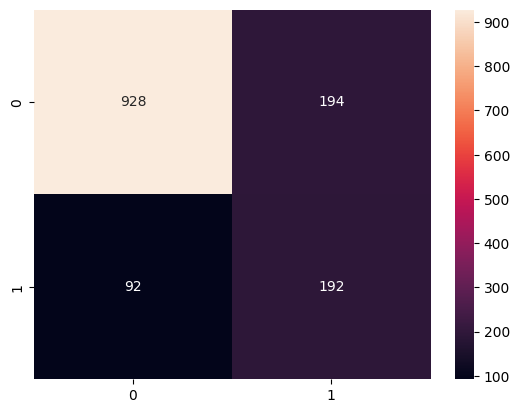

In [55]:
sns.heatmap(confusion_matrix(Y_pred,Y_test),annot=True,fmt='1')

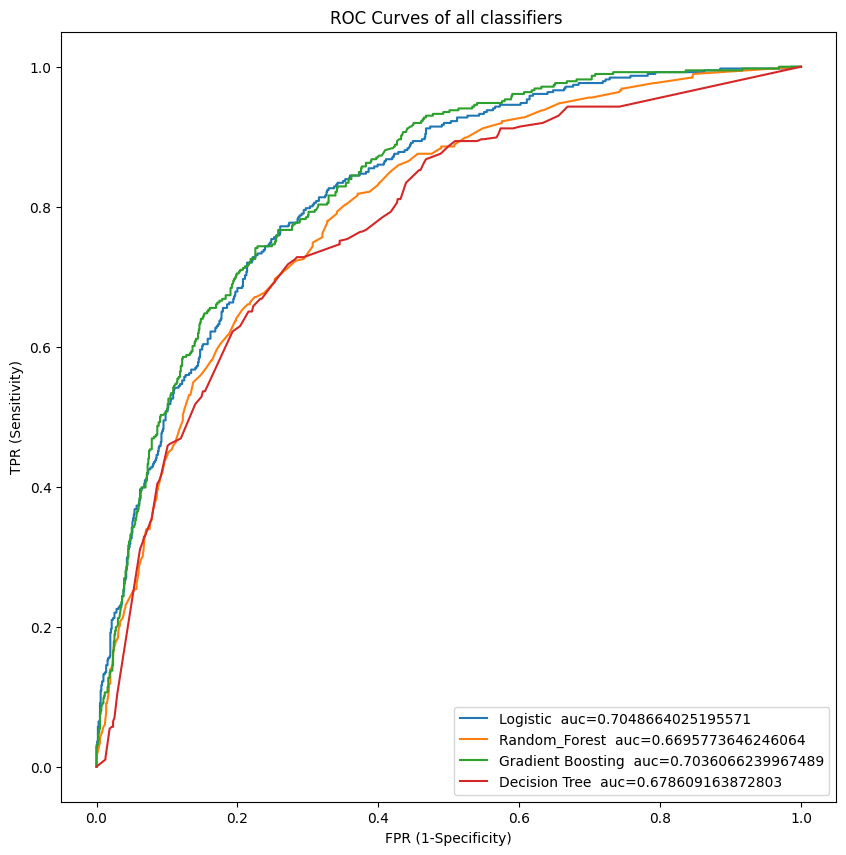

In [61]:
from sklearn.metrics import roc_curve, roc_auc_score
from sklearn.preprocessing import StandardScaler

# Scale the data
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

plt.figure(figsize=(10,10));
plt.title('ROC Curves of all classifiers ')
plt.xlabel('FPR (1-Specificity)')
plt.ylabel('TPR (Sensitivity)')
def model(clf,X_train,X_test,Y_train):

    clf.fit(X_train,Y_train)
    Y_pred,Y_probs=clf.predict(X_test),clf.predict_proba(X_test)[:,1]
    return  Y_pred,Y_probs

clfs = {
    'Logistic': LogisticRegression(max_iter=1000),
    'Random_Forest': RandomForestClassifier(),
    'Gradient Boosting': GradientBoostingClassifier(),
    'Decision Tree': DecisionTreeClassifier(max_depth=8, random_state=199),
}

for clf_name in clfs.keys():

    model =clfs[clf_name]  # select the model
    model.fit(X_train_scaled, Y_train)  # train the model with scaled data
    Y_pred = model.predict(X_test_scaled)  # predict the test data with scaled data
    fpr, tpr, thresholds = roc_curve(Y_test, model.predict_proba(X_test_scaled)[:, 1])
    # Calculate Area under the curve to display on the plot
    auc = roc_auc_score(Y_test, Y_pred)
    plt.plot(fpr,tpr,label=clf_name+"  auc="+str(auc));
    plt.legend(loc=4)

              precision    recall  f1-score   support

           0       0.68      0.88      0.76       784
           1       0.76      0.47      0.58       622

    accuracy                           0.70      1406
   macro avg       0.72      0.67      0.67      1406
weighted avg       0.71      0.70      0.68      1406



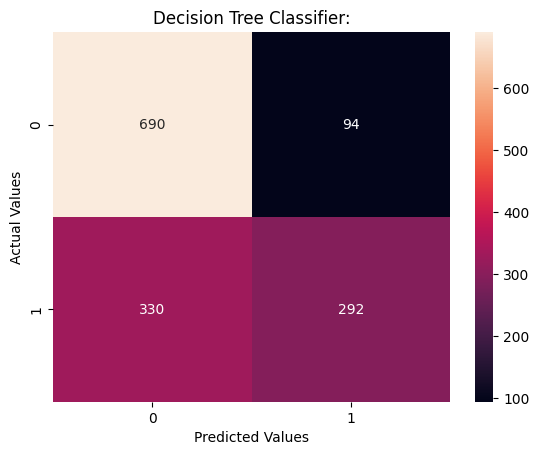

In [60]:
from sklearn.tree import DecisionTreeClassifier

dt_model = DecisionTreeClassifier(class_weight='balanced', max_depth=8, random_state=199)
dt_model.fit(X_train, Y_train)

Y_dt_pred = dt_model.predict(X_test)

print(classification_report(Y_dt_pred, Y_test))

sns.heatmap(confusion_matrix(Y_dt_pred, Y_test), annot=True, fmt='1')
plt.xlabel('Predicted Values')
plt.ylabel('Actual Values')
plt.title('Decision Tree Classifier:');

MODEL COMPARISON LEADERBOARD
                    Model  Accuracy  Precision  Recall  F1-Score  ROC-AUC
Rank                                                                     
1       Gradient Boosting    0.7966     0.6761  0.4974    0.5731   0.8321
2     Logistic Regression    0.7290     0.5041  0.7876    0.6148   0.8257
3           Random Forest    0.7752     0.6250  0.4534    0.5255   0.7995
4           Decision Tree    0.6984     0.4695  0.7565    0.5794   0.7805

🏆 Best-Performing Model: Gradient Boosting (ROC-AUC = 0.8321)


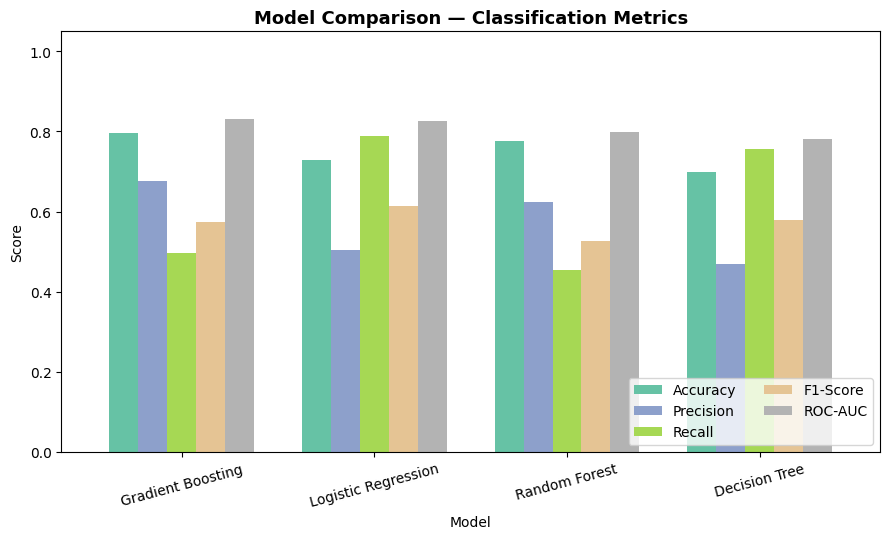


Saved model_leaderboard.csv


In [62]:
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, roc_auc_score

fitted_models = {
    "Logistic Regression": log_model,
    "Random Forest": rf_model,
    "Gradient Boosting": gb_clf,
    "Decision Tree": dt_model,
}

results = []

for name, clf in fitted_models.items():
    y_pred = clf.predict(X_test)
    y_proba = clf.predict_proba(X_test)[:, 1]

    results.append({
        "Model": name,
        "Accuracy": round(accuracy_score(Y_test, y_pred), 4),
        "Precision": round(precision_score(Y_test, y_pred), 4),
        "Recall": round(recall_score(Y_test, y_pred), 4),
        "F1-Score": round(f1_score(Y_test, y_pred), 4),
        "ROC-AUC": round(roc_auc_score(Y_test, y_proba), 4),
    })

leaderboard = pd.DataFrame(results).sort_values("ROC-AUC", ascending=False).reset_index(drop=True)
leaderboard.index = leaderboard.index + 1
leaderboard.index.name = "Rank"

print("MODEL COMPARISON LEADERBOARD")
print(leaderboard.to_string())

best_model = leaderboard.iloc[0]["Model"]
best_auc = leaderboard.iloc[0]["ROC-AUC"]
print(f"\n🏆 Best-Performing Model: {best_model} (ROC-AUC = {best_auc})")

metrics_to_plot = ["Accuracy", "Precision", "Recall", "F1-Score", "ROC-AUC"]
leaderboard.set_index("Model")[metrics_to_plot].plot(
    kind="bar", figsize=(9, 5.5), colormap="Set2", width=0.75
)
plt.title("Model Comparison — Classification Metrics", fontsize=13, fontweight="bold")
plt.ylabel("Score")
plt.xticks(rotation=15)
plt.ylim(0, 1.05)
plt.legend(loc="lower right", ncol=2)
plt.tight_layout()
plt.show()

leaderboard.to_csv("model_leaderboard.csv")
print("\nSaved model_leaderboard.csv")

Looking at the above AUC curve, we should pick either Logistic or Gradient Boosting Classifier.. Since GB Classifier has a fair recall. I'll go with GB Classifier.